In [2]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

#### 1. 数据质量检查

#####  检查是否还有缺失值

In [ ]:
model_data_path = '../data/processed/final_merged_dataset_cleaned.csv'
model_df = pd.read_csv(model_data_path)
print(model_df.isnull().sum())

origin_iso3              0
destination_iso3         0
migration_date           0
year                     0
month                    0
flow                     0
log_flow                 0
o_spei                   0
spei_date                0
o_MA                     0
o_gdp_pc                 0
o_pop                    0
o_urban                  0
o_unemp                  0
o_political_stability    0
d_gdp_pc                 0
d_pop                    0
d_urban                  0
d_unemp                  0
d_political_stability    0
border_friction_ij       0
control_distwces         0
dtype: int64


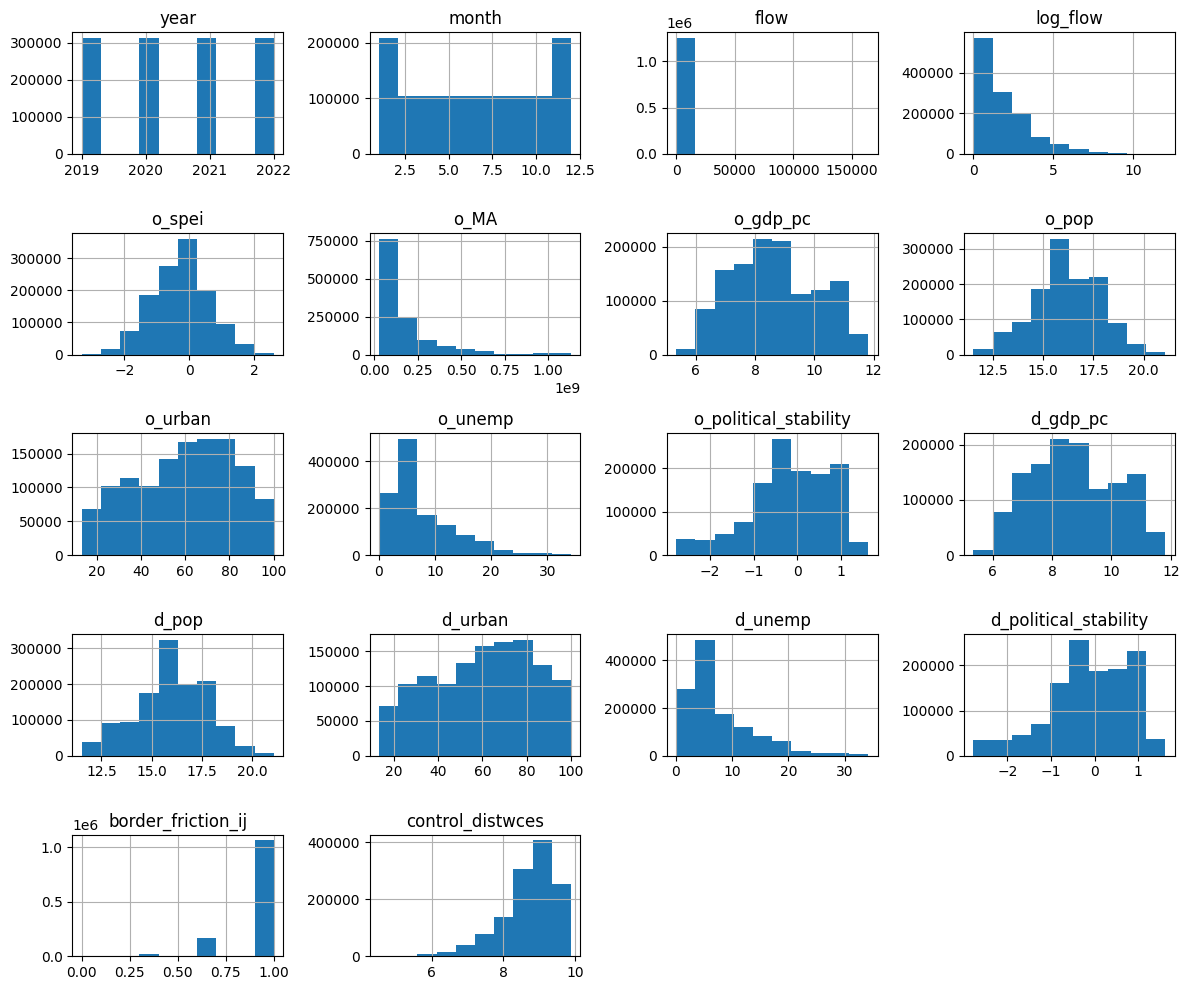

In [4]:
# 检查数据分布和异常值
model_df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

##### 时间变量处理
生成 唯一的时间 ID（方便做时间固定效应）：

In [9]:
# 创建 PeriodIndex
model_df['period'] = pd.to_datetime(model_df['migration_date']).dt.to_period('M')

##### 3. 双边 ID 创建
固定效应要区分国家对：

In [11]:
model_df['pair_id'] = model_df['origin_iso3'] + '-' + model_df['destination_iso3']


In [12]:
model_df

,origin_iso3,destination_iso3,migration_date,year,month,flow,log_flow,o_spei,spei_date,o_MA,...,o_political_stability,d_gdp_pc,d_pop,d_urban,d_unemp,d_political_stability,border_friction_ij,control_distwces,period,pair_id
0,ARE,AFG,2019-01-01,2019,1,221,5.402677,0.013769,2019-01-16,1.244197e+08,...,0.667538,6.197131,17.449303,25.754,11.196,-2.652540,1.000000,7.395659,2019-01,ARE-AFG
1,ARE,AFG,2019-02-01,2019,2,279,5.634790,-0.017917,2019-02-15,1.244197e+08,...,0.667538,6.197131,17.449303,25.754,11.196,-2.652540,1.000000,7.395659,2019-02,ARE-AFG
2,ARE,AFG,2019-03-01,2019,3,276,5.624018,0.490999,2019-03-16,1.244197e+08,...,0.667538,6.197131,17.449303,25.754,11.196,-2.652540,1.000000,7.395659,2019-03,ARE-AFG
3,ARE,AFG,2019-04-01,2019,4,418,6.037871,0.797000,2019-04-16,1.244197e+08,...,0.667538,6.197131,17.449303,25.754,11.196,-2.652540,1.000000,7.395659,2019-04,ARE-AFG
4,ARE,AFG,2019-05-01,2019,5,366,5.905362,0.580897,2019-05-16,1.244197e+08,...,0.667538,6.197131,17.449303,25.754,11.196,-2.652540,1.000000,7.395659,2019-05,ARE-AFG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250421,ZWE,ZMB,2022-08-01,2022,8,138,4.934474,0.326137,2022-08-16,5.312007e+07,...,-0.894974,7.027457,16.818861,45.761,5.199,0.161332,0.333333,6.263538,2022-08,ZWE-ZMB
1250422,ZWE,ZMB,2022-09-01,2022,9,162,5.093750,-0.502948,2022-09-16,5.312007e+07,...,-0.894974,7.027457,16.818861,45.761,5.199,0.161332,0.333333,6.263538,2022-09,ZWE-ZMB
1250423,ZWE,ZMB,2022-10-01,2022,10,149,5.010635,-0.593602,2022-10-16,5.312007e+07,...,-0.894974,7.027457,16.818861,45.761,5.199,0.161332,0.333333,6.263538,2022-10,ZWE-ZMB
1250424,ZWE,ZMB,2022-11-01,2022,11,104,4.653960,-0.331173,2022-11-16,5.312007e+07,...,-0.894974,7.027457,16.818861,45.761,5.199,0.161332,0.333333,6.263538,2022-11,ZWE-ZMB


#### 2. 探索性数据分析 (EDA)
通过可视化和统计分析，了解数据的基本特征：

<Axes: title={'center': 'Yearly Migration Flow'}, xlabel='year'>

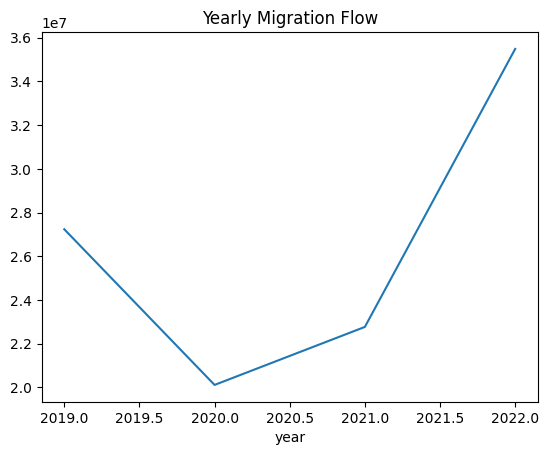

In [5]:
model_df.groupby('year')['flow'].sum().plot(kind='line', title='Yearly Migration Flow')

相关性分析：检查变量之间的相关性

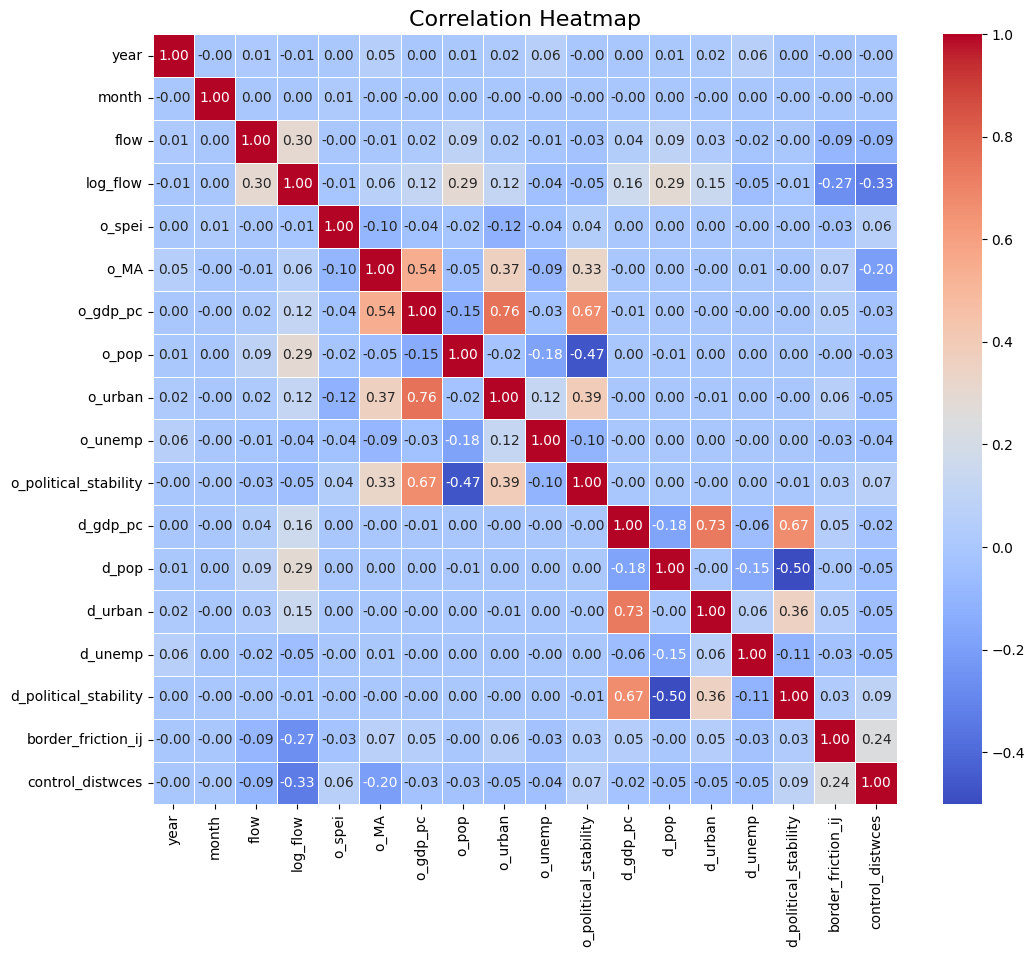

In [8]:
# 只选择数值列
numeric_cols = model_df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

# 绘制热力图，调整图表大小
plt.figure(figsize=(12, 10))  # 调整宽度和高度
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [ ]:
# === 数据准备 ===
# 确保数据是多重索引格式（PanelOLS 需要）
df_merged['year_month'] = df_merged['year'].astype(str) + '-' + df_merged['month'].astype(str)
df_merged = df_merged.set_index(['origin_iso3', 'destination_iso3', 'year_month'])

# === 模型定义 ===
# Baseline 模型
baseline_formula = 'log_flow ~ o_spei'

# 模型 2：+ o_MA 和交互项
model_2_formula = 'log_flow ~ o_spei + o_MA + o_spei:o_MA'

# 模型 3：+ border_friction_ij 和交互项
model_3_formula = 'log_flow ~ o_spei + border_friction_ij + o_spei:border_friction_ij'

# 模型 4：完整模型
model_4_formula = (
    'log_flow ~ o_spei + o_MA + border_friction_ij + o_spei:o_MA + o_spei:border_friction_ij + '
    'o_gdp_pc + o_pop + o_urban + o_unemp + o_political_stability + '
    'd_gdp_pc + d_pop + d_urban + d_unemp + d_political_stability + control_distwces'
)

# === 回归分析 ===
# 定义固定效应
df_merged['pair_fe'] = df_merged.index.get_level_values('origin_iso3') + '-' + df_merged.index.get_level_values('destination_iso3')
df_merged['time_fe'] = df_merged.index.get_level_values('year_month')

# 运行回归
models = {}
for name, formula in zip(
    ['Baseline', 'Model 2', 'Model 3', 'Model 4'],
    [baseline_formula, model_2_formula, model_3_formula, model_4_formula]
):
    models[name] = PanelOLS.from_formula(
        formula,
        data=df_merged,
        drop_absorbed=True
    ).fit(cov_type='clustered', cluster_entity=True)

# === 输出回归结果 ===
# 汇总结果表
results_table = summary_col(
    [models['Baseline'], models['Model 2'], models['Model 3'], models['Model 4']],
    stars=True,
    model_names=['Baseline', 'Model 2', 'Model 3', 'Model 4'],
    info_dict={'R²': lambda x: f"{x.rsquared:.3f}", 'N': lambda x: f"{x.nobs}"}
)
print(results_table)

# === 可视化交互效应 ===
# 计算边际效应
def marginal_effect_plot(model, interaction_var, moderator_var, moderator_values, xlabel, ylabel, title):
    marginal_effects = []
    for value in moderator_values:
        df_temp = df_merged.copy()
        df_temp[moderator_var] = value
        marginal_effect = model.params['o_spei'] + model.params[f'o_spei:{moderator_var}'] * value
        marginal_effects.append(marginal_effect)

    # 绘图
    plt.figure(figsize=(8, 6))
    plt.plot(moderator_values, marginal_effects, marker='o')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.5)
    plt.show()

# 可视化 MA 的交互效应
marginal_effect_plot(
    models['Model 2'],
    interaction_var='o_spei:o_MA',
    moderator_var='o_MA',
    moderator_values=np.linspace(df_merged['o_MA'].min(), df_merged['o_MA'].max(), 10),
    xlabel='Market Access (MA)',
    ylabel='Marginal Effect of SPEI on log_flow',
    title='Marginal Effect of SPEI on log_flow by MA'
)

# 可视化 Border Friction 的交互效应
marginal_effect_plot(
    models['Model 3'],
    interaction_var='o_spei:border_friction_ij',
    moderator_var='border_friction_ij',
    moderator_values=np.linspace(df_merged['border_friction_ij'].min(), df_merged['border_friction_ij'].max(), 10),
    xlabel='Border Friction',
    ylabel='Marginal Effect of SPEI on log_flow',
    title='Marginal Effect of SPEI on log_flow by Border Friction'
)